In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings
from requests.exceptions import RequestsDependencyWarning

warnings.filterwarnings("ignore", category=RequestsDependencyWarning)

C:\Users\Ayush Meshram\AppData\Roaming\Python\Python313\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
import sys
print(sys.executable)


C:\Python313\python.exe


In [3]:
import sys
!{sys.executable} -m pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable


In [4]:
dataset_path = r"C:\Users\Ayush Meshram\OneDrive\Dokumen\Driver Drowsiness Detection\Dataset\DDD"

# EDA

In [5]:
img_height = 224
img_width = 224
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 9119 files belonging to 2 classes.
Using 7296 files for training.
Found 9119 files belonging to 2 classes.
Using 1823 files for validation.


In [6]:
class_names = train_ds.class_names
print(class_names)

['Drowsy', 'Non Drowsy']


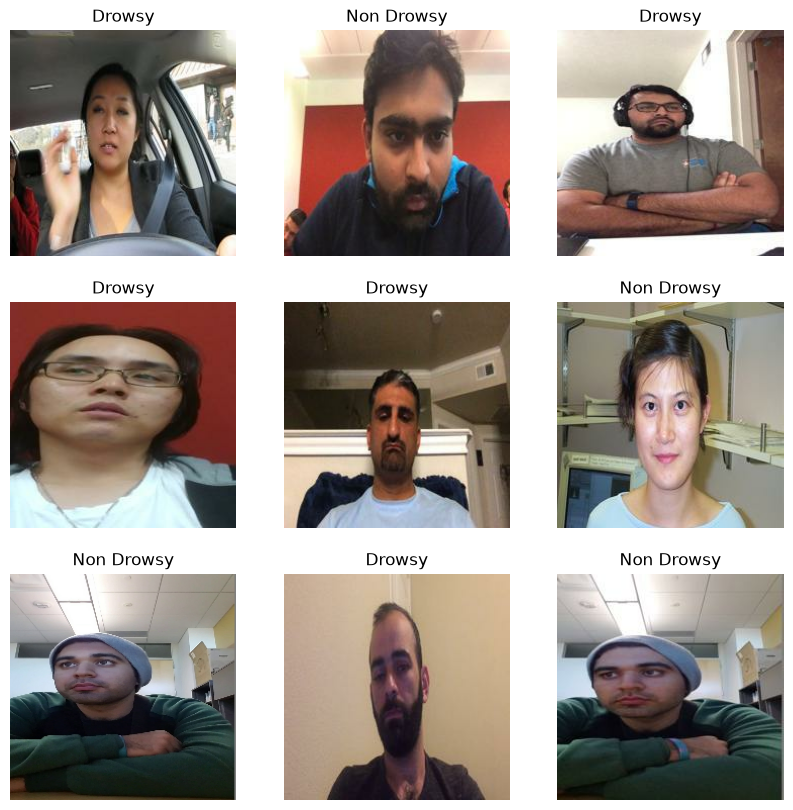

In [7]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [8]:
import os

dataset_path = r"C:\Users\Ayush Meshram\OneDrive\Dokumen\Driver Drowsiness Detection\Dataset\DDD"

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        count = len([
            f for f in os.listdir(folder_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])
        print(f"{folder}: {count} images")

Drowsy: 4560 images
Non Drowsy: 4559 images


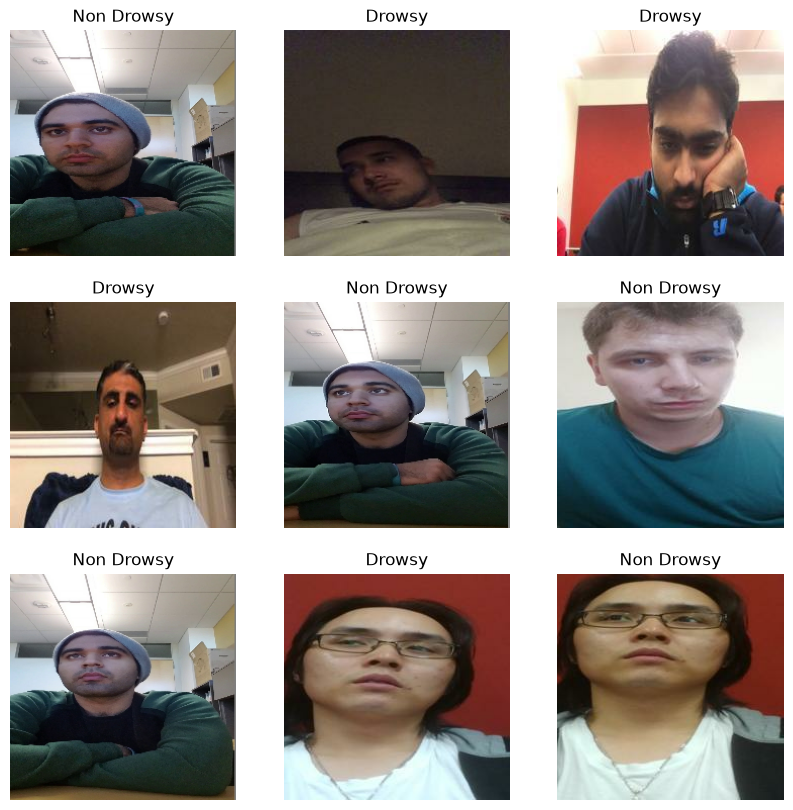

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [10]:
for images, labels in train_ds.take(1):
    print("Batch shape:", images.shape)
    print("Label shape:", labels.shape)

Batch shape: (32, 224, 224, 3)
Label shape: (32,)


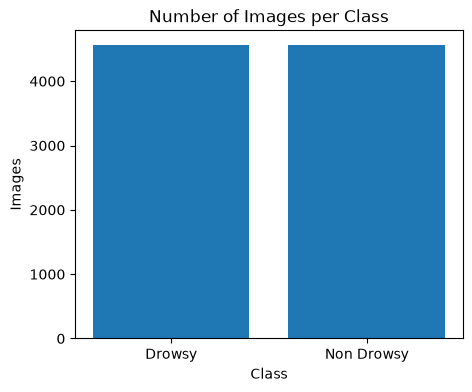

In [11]:
import os
import matplotlib.pyplot as plt

classes = []
counts = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        classes.append(folder)
        counts.append(count)

plt.figure(figsize=(5,4))
plt.bar(classes, counts)
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Images")
plt.show()

In [12]:
from PIL import Image
import os

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    for file in os.listdir(folder_path)[:5]:
        img = Image.open(os.path.join(folder_path, file))
        print(folder, file, img.size)

Drowsy 0.jpg (224, 224)
Drowsy 00.jpg (224, 224)
Drowsy 1.jpg (224, 224)
Drowsy 10.jpg (224, 224)
Drowsy 11.jpg (224, 224)
Non Drowsy image_0 (10).jpg (224, 224)
Non Drowsy image_0 (15).jpg (224, 224)
Non Drowsy image_0 (3).jpg (224, 224)
Non Drowsy image_0 (4).jpg (224, 224)
Non Drowsy image_0 (5).jpg (224, 224)


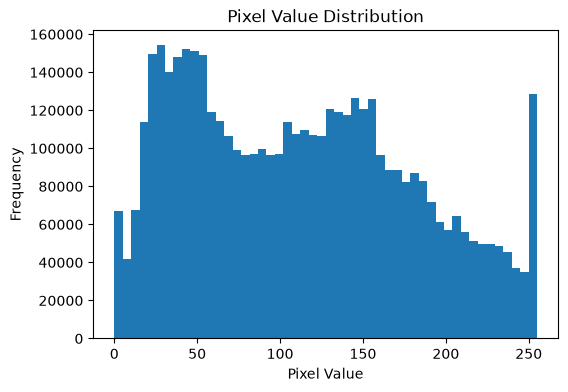

In [13]:
import numpy as np

for images, labels in train_ds.take(1):
    plt.figure(figsize=(6,4))
    plt.hist(images.numpy().flatten(), bins=50)
    plt.title("Pixel Value Distribution")
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.show()

In [14]:
normalization_layer = layers.Rescaling(1./255)

In [15]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.05,0.05)
])

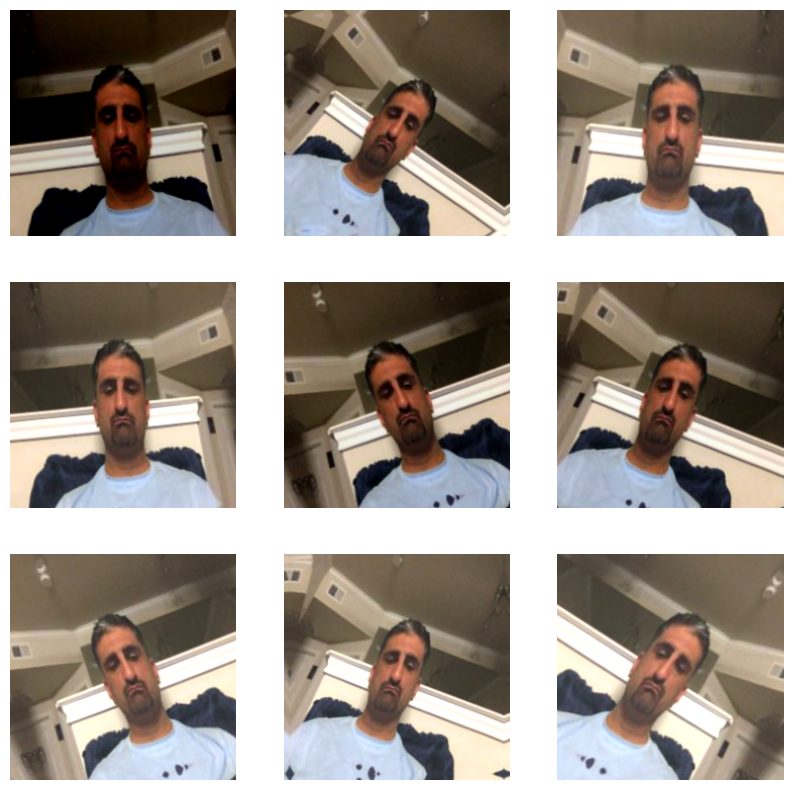

In [16]:
plt.figure(figsize=(10,10))

for images, _ in train_ds.take(1):
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        augmented = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented[0].numpy().astype("uint8"))
        plt.axis("off")

plt.show()

In [17]:
from PIL import Image
import os

dataset_path = r"C:\Users\Ayush Meshram\OneDrive\Dokumen\Driver Drowsiness Detection\Dataset\DDD"

bad_images = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            path = os.path.join(root, file)
            try:
                with Image.open(path) as img:
                    img.load()   # Force the image to be fully read
            except Exception as e:
                bad_images.append((path, str(e)))

print("Bad images found:", len(bad_images))

for path, err in bad_images:
    print(path)
    print(err)
    

Bad images found: 0


# Model Training

In [18]:
IMG_SIZE = (224, 224)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

In [19]:
base_model.trainable = False

In [20]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

model = keras.Sequential([
    layers.Input(shape=(224,224,3)),

    data_augmentation,

    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [22]:
epochs = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10


C:\Users\Ayush Meshram\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


228/228 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - accuracy: 0.7708 - loss: 0.4616 - val_accuracy: 0.8064 - val_loss: 0.3875
Epoch 2/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 326s 1s/step - accuracy: 0.8091 - loss: 0.3753 - val_accuracy: 0.8053 - val_loss: 0.3791
Epoch 3/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 310s 1s/step - accuracy: 0.8177 - loss: 0.3617 - val_accuracy: 0.8321 - val_loss: 0.3488
Epoch 4/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 339s 1s/step - accuracy: 0.8306 - loss: 0.3394 - val_accuracy: 0.8300 - val_loss: 0.3476
Epoch 5/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 285s 1s/step - accuracy: 0.8390 - loss: 0.3339 - val_accuracy: 0.8502 - val_loss: 0.3305
Epoch 6/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.8457 - loss: 0.3248 - val_accuracy: 0.8535 - val_loss: 0.3224
Epoch 7/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.8410 - loss: 0.3224 - val_accuracy: 0.7866 - val_loss: 0.3850
Epoch 8/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 302s 1s/step - accuracy: 0.8498 - loss: 0.3119 - val_accuracy: 0.821

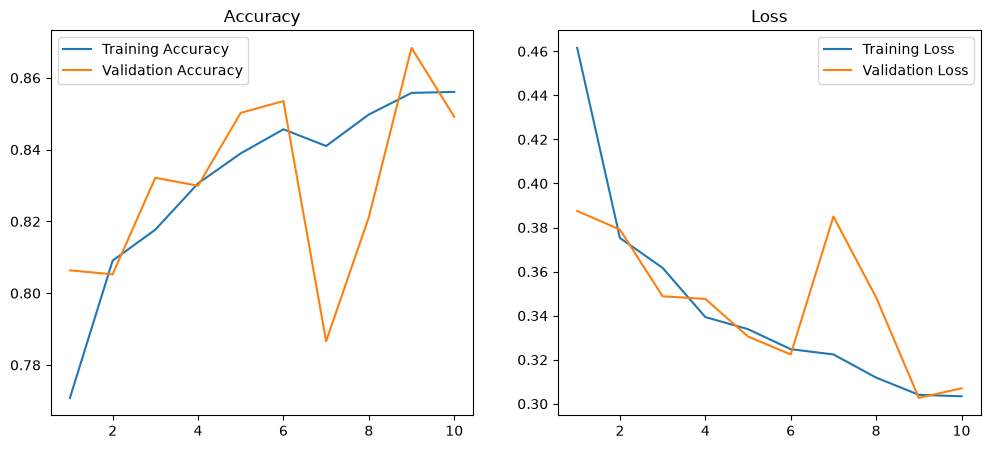

In [23]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [24]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

57/57 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.8491 - loss: 0.3070
Validation Loss: 0.30703794956207275
Validation Accuracy: 0.849149763584137


In [37]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

print(confusion_matrix(y_true, y_pred))

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

[[716 221]
 [ 54 832]]
              precision    recall  f1-score   support

      Drowsy       0.93      0.76      0.84       937
  Non Drowsy       0.79      0.94      0.86       886

    accuracy                           0.85      1823
   macro avg       0.86      0.85      0.85      1823
weighted avg       0.86      0.85      0.85      1823



# Fine tuning

In [38]:
base_model.trainable = True

In [39]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [40]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [42]:
base_model.trainable = True

In [43]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [44]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [45]:
fine_tune_epochs = 10

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs
)

Epoch 1/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 309s 1s/step - accuracy: 0.8494 - loss: 0.3078 - val_accuracy: 0.8662 - val_loss: 0.3043
Epoch 2/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 302s 1s/step - accuracy: 0.8621 - loss: 0.2940 - val_accuracy: 0.8629 - val_loss: 0.3094
Epoch 3/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 312s 1s/step - accuracy: 0.8672 - loss: 0.2837 - val_accuracy: 0.8656 - val_loss: 0.3076
Epoch 4/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - accuracy: 0.8753 - loss: 0.2713 - val_accuracy: 0.8700 - val_loss: 0.2824
Epoch 5/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - accuracy: 0.8802 - loss: 0.2661 - val_accuracy: 0.8886 - val_loss: 0.2585
Epoch 6/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 308s 1s/step - accuracy: 0.8862 - loss: 0.2533 - val_accuracy: 0.8777 - val_loss: 0.2815
Epoch 7/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.8893 - loss: 0.2439 - val_accuracy: 0.8821 - val_loss: 0.2671
Epoch 8/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 325s 1s/step - accuracy: 0.8942 - loss: 0.2431 - val_accu

In [46]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_driver_drowsiness.keras",
    monitor="val_accuracy",
    save_best_only=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.8909 - loss: 0.2348 - val_accuracy: 0.8705 - val_loss: 0.2945
Epoch 2/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.9012 - loss: 0.2189 - val_accuracy: 0.8837 - val_loss: 0.2671
Epoch 3/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.9017 - loss: 0.2223 - val_accuracy: 0.8826 - val_loss: 0.2737
Epoch 4/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.9009 - loss: 0.2188 - val_accuracy: 0.8897 - val_loss: 0.2629
Epoch 5/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.9067 - loss: 0.2134 - val_accuracy: 0.8941 - val_loss: 0.2566
Epoch 6/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.9028 - loss: 0.2163 - val_accuracy: 0.8865 - val_loss: 0.2868
Epoch 7/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.9087 - loss: 0.2128 - val_accuracy: 0.9002 - val_loss: 0.2504
Epoch 8/20
228/228 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.9101 - loss: 0.2073 - val_accu

In [47]:



from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import seaborn as sns

In [48]:
y_true = []
y_pred = []
y_prob = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_prob.extend(predictions.ravel())
    y_pred.extend((predictions > 0.5).astype(int).ravel())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

In [49]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Drowsy","Non Drowsy"]
))

Accuracy : 0.9188151398793198
Precision: 0.8867924528301887
Recall   : 0.9548532731376975
F1-Score : 0.9195652173913044

Classification Report:

              precision    recall  f1-score   support

      Drowsy       0.95      0.88      0.92       937
  Non Drowsy       0.89      0.95      0.92       886

    accuracy                           0.92      1823
   macro avg       0.92      0.92      0.92      1823
weighted avg       0.92      0.92      0.92      1823



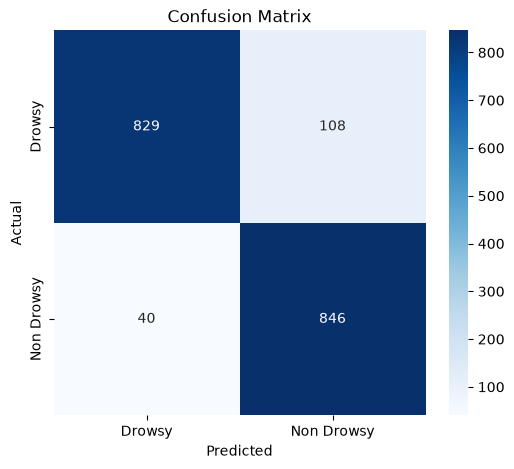

In [50]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Drowsy","Non Drowsy"],
    yticklabels=["Drowsy","Non Drowsy"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

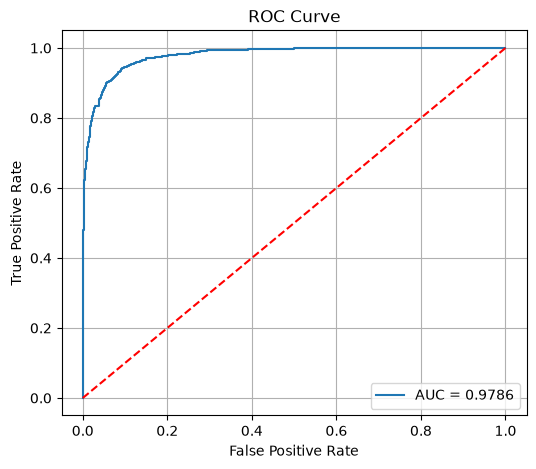

AUC Score: 0.9786058960565274


In [51]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print("AUC Score:", auc)

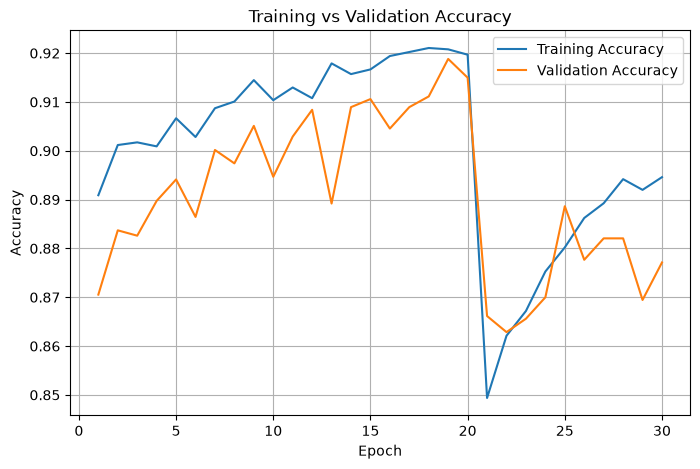

In [52]:
train_acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

epochs = range(1, len(train_acc)+1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

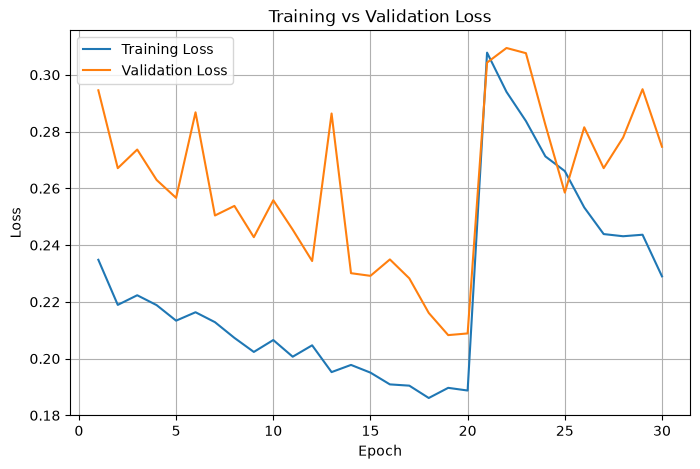

In [53]:
train_loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

epochs = range(1, len(train_loss)+1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [54]:
train_acc = history.history['accuracy'] + history_fine.history['accuracy']

In [58]:
model.save("driver_drowsiness_model.keras")

In [59]:
model = tf.keras.models.load_model("driver_drowsiness_model.keras")

In [64]:
img_path = r"C:\Users\Ayush Meshram\OneDrive\Dokumen\DDD\Non Drowsy\image__841.jpg"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Prediction: Non Drowsy
Confidence: 92.02%


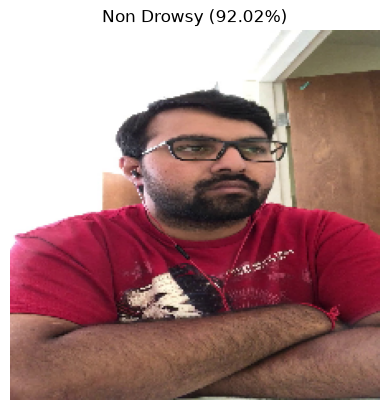

In [71]:
# Load image
img = image.load_img(img_path, target_size=(224, 224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize


# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)

probability = prediction[0][0]

plt.imshow(img)
plt.axis("off")

if probability < 0.5:
    print(f"Prediction: Drowsy")
    print(f"Confidence: {(1-probability)*100:.2f}%")
    plt.title(f"Drowsy ({(1-probability)*100:.2f}%)")
else:
    print(f"Prediction: Non Drowsy")
    print(f"Confidence: {probability*100:.2f}%")
    plt.title(f"Non Drowsy ({probability*100:.2f}%)")

plt.show()

In [72]:
prediction = model.predict(img_array, verbose=0)

print("Raw prediction:", prediction)
print("Probability:", prediction[0][0])

Raw prediction: [[0.9201619]]
Probability: 0.9201619


In [73]:
print(train_ds.class_names)

['Drowsy', 'Non Drowsy']


In [74]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_1 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,162,437 (19.69 MB)

 Trainable params: 1,370,177 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 2,740,356 (10.45 MB)

In [75]:
layers.Rescaling(1./255)

<Rescaling name=rescaling_3, built=False>

In [77]:
img_path = r"C:\Users\Ayush Meshram\OneDrive\Dokumen\DDD\Non Drowsy\image_0434.jpg"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
Prediction: Non Drowsy
Confidence: 98.89%


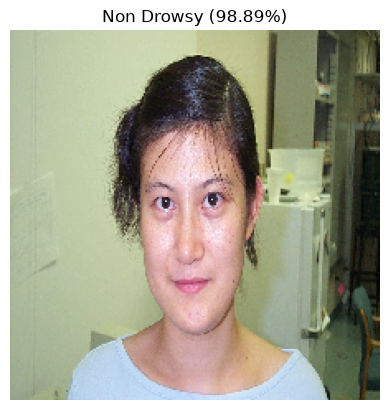

In [78]:
# Load image
img = image.load_img(img_path, target_size=(224, 224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize


# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)

probability = prediction[0][0]

plt.imshow(img)
plt.axis("off")

if probability < 0.5:
    print(f"Prediction: Drowsy")
    print(f"Confidence: {(1-probability)*100:.2f}%")
    plt.title(f"Drowsy ({(1-probability)*100:.2f}%)")
else:
    print(f"Prediction: Non Drowsy")
    print(f"Confidence: {probability*100:.2f}%")
    plt.title(f"Non Drowsy ({probability*100:.2f}%)")

plt.show()

In [79]:
img_path = r"C:\Users\Ayush Meshram\OneDrive\Dokumen\DDD\Drowsy\40.jpg"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Prediction: Drowsy
Confidence: 92.15%


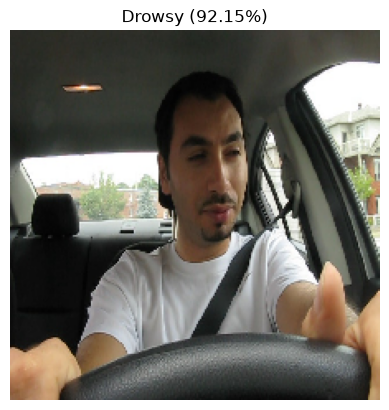

In [80]:
# Load image
img = image.load_img(img_path, target_size=(224, 224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize


# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)

probability = prediction[0][0]

plt.imshow(img)
plt.axis("off")

if probability < 0.5:
    print(f"Prediction: Drowsy")
    print(f"Confidence: {(1-probability)*100:.2f}%")
    plt.title(f"Drowsy ({(1-probability)*100:.2f}%)")
else:
    print(f"Prediction: Non Drowsy")
    print(f"Confidence: {probability*100:.2f}%")
    plt.title(f"Non Drowsy ({probability*100:.2f}%)")

plt.show()

In [81]:
img_path = r"C:\Users\Ayush Meshram\OneDrive\Dokumen\DDD\Drowsy\image_0163.jpg"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
Prediction: Drowsy
Confidence: 56.36%


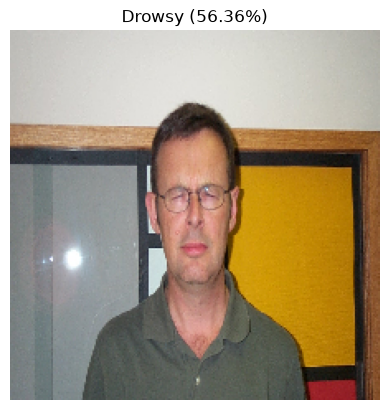

In [82]:
# Load image
img = image.load_img(img_path, target_size=(224, 224))

# Convert to array
img_array = image.img_to_array(img)

# Normalize


# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)

probability = prediction[0][0]

plt.imshow(img)
plt.axis("off")

if probability < 0.5:
    print(f"Prediction: Drowsy")
    print(f"Confidence: {(1-probability)*100:.2f}%")
    plt.title(f"Drowsy ({(1-probability)*100:.2f}%)")
else:
    print(f"Prediction: Non Drowsy")
    print(f"Confidence: {probability*100:.2f}%")
    plt.title(f"Non Drowsy ({probability*100:.2f}%)")

plt.show()

In [95]:
img_path = r"C:\Users\Ayush Meshram\OneDrive\Desktop\WhatsApp Image 2026-08-01 at 3.54.15 PM.jpeg"

Raw Prediction: 0.782809
Prediction : Non Drowsy
Confidence : 78.28%


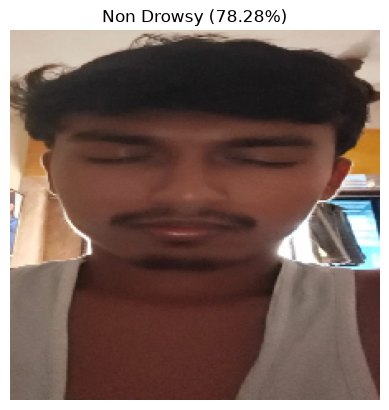

In [101]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Path of the image
img_path = r"C:\Users\Ayush Meshram\OneDrive\Desktop\WhatsApp Image 2026-07-28 at 1.56.05 PM.jpeg"

# Load image
img = image.load_img(img_path, target_size=(224, 224))

# Display image
plt.imshow(img)
plt.axis("off")

# Convert to array
img_array = image.img_to_array(img)

# IMPORTANT: Do NOT normalize here because the model already has a Rescaling layer
# img_array = img_array / 255.0   <-- Remove this line

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array, verbose=0)
probability = prediction[0][0]

print(f"Raw Prediction: {probability:.6f}")

# Class names (same as training)
class_names = ['Drowsy', 'Non Drowsy']

if probability < 0.5:
    predicted_class = class_names[0]
    confidence = (1 - probability) * 100
else:
    predicted_class = class_names[1]
    confidence = probability * 100

print(f"Prediction : {predicted_class}")
print(f"Confidence : {confidence:.2f}%")

plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.show()